In [14]:
# Did a lack of major third party support attribute to lower sales
# of games on the Wii U, especially when compared to the sales of
# games on other consoles released from 1980 to 2017?

## Importing Dataframe and Removing Unnecessary Columns

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

games_nan = pd.read_csv('Video_Games.csv', sep=',', header=0)

# Convert 'User_Score' and 'Critic_Score' to numeric, coercing errors and filling NaNs with 0
games_nan['User_Score'] = pd.to_numeric(games_nan['User_Score'], errors='coerce').fillna(0)
games_nan['Critic_Score'] = pd.to_numeric(games_nan['Critic_Score'], errors='coerce').fillna(0)

# Drop the 'Rating' and 'Developer' column
games_new = games_nan.drop('Rating', axis=1)
games_new_2 = games_new.drop('Developer', axis=1)

# Drop rows of games on more obscure columns or have incomplete data
games_filtered = games_new_2[games_new_2['Platform'] != 'GEN']
games_filtered_2 = games_filtered[games_filtered['Platform'] != 'DC']
games_filtered_3 = games_filtered_2[games_filtered_2['Platform'] != 'SCD']
games_filtered_4 = games_filtered_3[games_filtered_3['Platform'] != 'NG']
games_filtered_5 = games_filtered_4[games_filtered_4['Platform'] != 'WS']
games_filtered_6 = games_filtered_5[games_filtered_5['Platform'] != 'TG16']
games_filtered_7 = games_filtered_6[games_filtered_6['Platform'] != '3DO']
games_filtered_8 = games_filtered_7[games_filtered_7['Platform'] != 'GG']
games_filtered_9 = games_filtered_8[games_filtered_8['Platform'] != 'PCFX']

games_filtered_9.columns = games_filtered_9.columns.str.replace('Year_of_Release', 'Year of Release')
games_filtered_9.columns = games_filtered_9.columns.str.replace('NA_Sales', 'NA Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('EU_Sales', 'EU Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('JP_Sales', 'JP Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('Other_Sales', 'Other Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('Global_Sales', 'Global Sales')
games_filtered_9.columns = games_filtered_9.columns.str.replace('Critic_Score', 'Critic Score')
games_filtered_9.columns = games_filtered_9.columns.str.replace('Critic_Count', 'Critic Count')
games_filtered_9.columns = games_filtered_9.columns.str.replace('User_Score', 'User Score')
games_filtered_9.columns = games_filtered_9.columns.str.replace('User_Count', 'User Count')

# Fill remaining NaN values with 0 in the DataFrame
games = games_filtered_9.fillna(0)

In [25]:
games.head(10)

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,0.0,0.0,0.0,0.0
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,0.0,0.0,0.0,0.0
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,0.0,0.0,0.0,0.0
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,0.0,0.0,0.0,0.0


In [26]:
games.columns

Index(['Name', 'Platform', 'Year of Release', 'Genre', 'Publisher', 'NA Sales',
       'EU Sales', 'JP Sales', 'Other Sales', 'Global Sales', 'Critic Score',
       'Critic Count', 'User Score', 'User Count'],
      dtype='object')

## Adding Missing Values (according to Metacritic)

In [149]:
nintendo_count = games[(games['Publisher'] == 'Nintendo') & (games['Platform'] == 'WiiU')]
sony_count = games[(games['Publisher'] == 'Sony Computer Entertainment') & (games['Platform'] == 'PS4')]
microsoft_count = games[(games['Publisher'] == 'Microsoft Game Studios') & (games['Platform'] == 'XOne')]
nintendo_zero = nintendo_count[nintendo_count['Critic Score'] == 0]

In [150]:
games.loc[games['Name'] == 'Super Smash Bros. for Wii U and 3DS', 'Critic Score'] = 92
games.loc[games['Name'] == 'The Legend of Zelda: The Wind Waker', 'Critic Score'] = 90
games.loc[games['Name'] == 'Mario & Sonic at the Sochi 2014 Olympic Winter Games', 'Critic Score'] = 55
games.loc[games['Name'] == 'Monster Hunter Tri', 'Critic Score'] = 84
games.loc[games['Name'] == 'Mario & Sonic at the Rio 2016 Olympic Games', 'Critic Score'] = 60
games.loc[games['Name'] == 'Shin Megami Tensei x Fire Emblem', 'Critic Score'] = 80
games.loc[games['Name'] == 'Game & Wario', 'Critic Score'] = 61
games.loc[games['Name'] == 'Ninja Gaiden 3', 'Critic Score'] = 69
games.loc[games['Name'] == 'Just Dance Wii U', 'Critic Score'] = 80

games.loc[games['Name'] == 'Super Smash Bros. for Wii U and 3DS', 'User Score'] = 8.0
games.loc[games['Name'] == 'The Legend of Zelda: The Wind Waker', 'User Score'] = 9.0
games.loc[games['Name'] == 'Mario & Sonic at the Sochi 2014 Olympic Winter Games', 'User Score'] = 6.6
games.loc[games['Name'] == 'Monster Hunter Tri', 'User Score'] = 8.3
games.loc[games['Name'] == 'Mario & Sonic at the Rio 2016 Olympic Games', 'User Score'] = 6.4
games.loc[games['Name'] == 'Shin Megami Tensei x Fire Emblem', 'User Score'] = 7.9
games.loc[games['Name'] == 'Game & Wario', 'User Score'] = 6.9
games.loc[games['Name'] == 'Ninja Gaiden 3', 'User Score'] = 7.4
games.loc[games['Name'] == 'Just Dance Wii U', 'User Score'] = 8.0

games.loc[games['Name'] == 'Super Smash Bros. for Wii U and 3DS', 'Critic Count'] = 77
games.loc[games['Name'] == 'The Legend of Zelda: The Wind Waker', 'Critic Count'] = 70
games.loc[games['Name'] == 'Mario & Sonic at the Sochi 2014 Olympic Winter Games', 'Critic Count'] = 36
games.loc[games['Name'] == 'Monster Hunter Tri', 'Critic Count'] = 70
games.loc[games['Name'] == 'Mario & Sonic at the Rio 2016 Olympic Games', 'Critic Count'] = 30
games.loc[games['Name'] == 'Shin Megami Tensei x Fire Emblem', 'Critic Count'] = 62
games.loc[games['Name'] == 'Game & Wario', 'Critic Count'] = 60
games.loc[games['Name'] == 'Ninja Gaiden 3', 'Critic Count'] = 41
games.loc[games['Name'] == 'Just Dance Wii U', 'Critic Count'] = 8

games.loc[games['Name'] == 'Super Smash Bros. for Wii U and 3DS', 'User Count'] = 2353
games.loc[games['Name'] == 'The Legend of Zelda: The Wind Waker', 'User Count'] = 1610
games.loc[games['Name'] == 'Mario & Sonic at the Sochi 2014 Olympic Winter Games', 'User Count'] = 96
games.loc[games['Name'] == 'Monster Hunter Tri', 'User Count'] = 190
games.loc[games['Name'] == 'Mario & Sonic at the Rio 2016 Olympic Games', 'User Count'] = 78
games.loc[games['Name'] == 'Shin Megami Tensei x Fire Emblem', 'User Count'] = 394
games.loc[games['Name'] == 'Game & Wario', 'User Count'] = 151
games.loc[games['Name'] == 'Ninja Gaiden 3', 'User Count'] = 174
games.loc[games['Name'] == 'Just Dance Wii U', 'User Count'] = 8

nintendo_count = games[(games['Publisher'] == 'Nintendo') & (games['Platform'] == 'WiiU')]
nintendo_count.head(5)

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count,User ount,Critic_Score,User_Score,Critic_Count,User_Count
110,Mario Kart 8,WiiU,2014.0,Racing,Nintendo,3.15,2.15,1.28,0.51,7.09,88.0,82.0,9.1,1599.0,NaN,NaN,NaN,NaN,NaN
185,New Super Mario Bros. U,WiiU,2012.0,Platform,Nintendo,2.30,1.34,1.27,0.32,5.22,84.0,70.0,8.1,733.0,NaN,NaN,NaN,NaN,NaN
216,Super Smash Bros. for Wii U and 3DS,WiiU,2014.0,Fighting,Nintendo,2.60,1.08,0.81,0.38,4.87,92.0,77.0,8.0,2353.0,NaN,NaN,NaN,NaN,NaN
247,Splatoon,WiiU,2015.0,Shooter,Nintendo,1.54,1.18,1.46,0.26,4.43,81.0,88.0,8.5,1184.0,NaN,NaN,NaN,NaN,NaN
248,Nintendo Land,WiiU,2012.0,Misc,Nintendo,2.52,1.11,0.46,0.33,4.42,77.0,61.0,7.9,471.0,NaN,NaN,NaN,NaN,NaN


In [151]:
sony_zero = sony_count[sony_count['Critic Score'] == 0]
sony_zero

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count,User ount,Critic_Score,User_Score,Critic_Count,User_Count


In [152]:
games.loc[games['Name'] == 'The Last of Us', 'Critic Score'] = 95
games.loc[games['Name'] == 'Ratchet & Clank (2016)', 'Critic Score'] = 85
games.loc[games['Name'] == 'MLB 16: The Show', 'Critic Score'] = 85
games.loc[games['Name'] == 'God of War III', 'Critic Score'] = 92
games.loc[games['Name'] == 'The Heavy Rain and Beyond: Two Souls Collection', 'Critic Score'] = 78

games.loc[games['Name'] == 'The Last of Us', 'User Score'] = 9.2
games.loc[games['Name'] == 'Ratchet & Clank (2016)', 'User Score'] = 8.3
games.loc[games['Name'] == 'MLB 16: The Show', 'User Score'] = 7.3
games.loc[games['Name'] == 'God of War III', 'User Score'] = 9.0
games.loc[games['Name'] == 'The Heavy Rain and Beyond: Two Souls Collection', 'User Score'] = 8.4

games.loc[games['Name'] == 'The Last of Us', 'Critic Count'] = 95
games.loc[games['Name'] == 'Ratchet & Clank (2016)', 'Critic Count'] = 85
games.loc[games['Name'] == 'MLB 16: The Show', 'Critic Count'] = 85
games.loc[games['Name'] == 'God of War III', 'Critic Count'] = 92
games.loc[games['Name'] == 'The Heavy Rain and Beyond: Two Souls Collection', 'Critic Count'] = 78

games.loc[games['Name'] == 'The Last of Us', 'User ount'] = 9.2
games.loc[games['Name'] == 'Ratchet & Clank (2016)', 'User Count'] = 8.3
games.loc[games['Name'] == 'MLB 16: The Show', 'User Count'] = 7.3
games.loc[games['Name'] == 'God of War III', 'User Count'] = 9.0
games.loc[games['Name'] == 'The Heavy Rain and Beyond: Two Souls Collection', 'User Count'] = 8.4

sony_count = games[(games['Publisher'] == 'Sony Computer Entertainment') & (games['Platform'] == 'PS4')]
sony_count.head(5)

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count,User ount,Critic_Score,User_Score,Critic_Count,User_Count
171,Uncharted 4: A Thief's End,PS4,2016.0,Shooter,Sony Computer Entertainment,1.85,2.50,0.19,0.85,5.38,93.0,113.0,7.9,7064.0,NaN,NaN,NaN,NaN,NaN
225,The Last of Us,PS4,2014.0,Action,Sony Computer Entertainment,1.88,2.00,0.07,0.77,4.71,95.0,95.0,9.2,0.0,9.2,NaN,NaN,NaN,NaN
231,Uncharted: The Nathan Drake Collection,PS4,2015.0,Action,Sony Computer Entertainment,2.07,1.71,0.08,0.76,4.62,86.0,78.0,8.1,1264.0,NaN,NaN,NaN,NaN,NaN
529,inFAMOUS: Second Son,PS4,2014.0,Action,Sony Computer Entertainment,1.28,0.98,0.07,0.46,2.79,80.0,90.0,7.9,2944.0,NaN,NaN,NaN,NaN,NaN
560,Killzone: Shadow Fall,PS4,2013.0,Shooter,Sony Computer Entertainment,0.89,1.33,0.08,0.39,2.69,73.0,88.0,6.8,2102.0,NaN,NaN,NaN,NaN,NaN


In [205]:
microsoft_zero = microsoft_count[microsoft_count['Critic Score'] == 0]
microsoft_zero

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count,User ount,Critic_Score,User_Score,Critic_Count,User_Count
543,Minecraft,XOne,2014.0,Misc,Microsoft Game Studios,1.61,0.90,0.0,0.25,2.76,0.0,0.0,0.0,0.0,NaN,88.0,8.4,88.0,8.4
5190,Zoo Tycoon (2013),XOne,2013.0,Simulation,Microsoft Game Studios,0.18,0.15,0.0,0.03,0.36,0.0,0.0,0.0,0.0,NaN,68.0,4.0,68.0,4.0
7417,State of Decay,XOne,2015.0,Strategy,Microsoft Game Studios,0.14,0.05,0.0,0.02,0.21,0.0,0.0,0.0,0.0,NaN,78.0,7.8,78.0,7.8
11773,Killer Instinct (2013),XOne,2013.0,Fighting,Microsoft Game Studios,0.04,0.03,0.0,0.01,0.07,0.0,0.0,0.0,0.0,NaN,73.0,6.6,73.0,6.6


In [260]:
games.loc[games['Name'] == 'Minecraft', 'Critic Score'] = 88
games.loc[games['Name'] == 'Zoo Tycoon (2013)', 'Critic Score'] = 68
games.loc[games['Name'] == 'State of Decay', 'Critic Score'] = 78
games.loc[games['Name'] == 'Killer Instinct (2013)', 'Critic Score'] = 73

games.loc[games['Name'] == 'Minecraft', 'User Score'] = 8.4
games.loc[games['Name'] == 'Zoo Tycoon (2013)', 'User Score'] = 4.0
games.loc[games['Name'] == 'State of Decay', 'User Score'] = 7.8
games.loc[games['Name'] == 'Killer Instinct (2013)', 'User Score'] = 6.6

games.loc[games['Name'] == 'Minecraft', 'Critic Count'] = 88
games.loc[games['Name'] == 'Zoo Tycoon (2013)', 'Critic Count'] = 68
games.loc[games['Name'] == 'State of Decay', 'Critic Count'] = 78
games.loc[games['Name'] == 'Killer Instinct (2013)', 'Critic Count'] = 73

games.loc[games['Name'] == 'Minecraft', 'User Count'] = 8.4
games.loc[games['Name'] == 'Zoo Tycoon (2013)', 'User Count'] = 4.0
games.loc[games['Name'] == 'State of Decay', 'User Count'] = 7.8
games.loc[games['Name'] == 'Killer Instinct (2013)', 'User Count'] = 6.6

microsoft_count = games[(games['Publisher'] == 'Microsoft Game Studios') & (games['Platform'] == 'XOne')]
microsoft_count.head(5)

,Name,Platform,Year of Release,Genre,Publisher,NA Sales,EU Sales,JP Sales,Other Sales,Global Sales,Critic Score,Critic Count,User Score,User Count,User ount,Critic_Score,User_Score,Critic_Count,User_Count
242,Halo 5: Guardians,XOne,2015.0,Shooter,Microsoft Game Studios,2.78,1.27,0.03,0.41,4.48,84.0,101.0,6.4,2438.0,NaN,NaN,NaN,NaN,NaN
413,Gears of War: Ultimate Edition,XOne,2015.0,Shooter,Microsoft Game Studios,2.61,0.33,0.00,0.34,3.28,82.0,74.0,7.5,563.0,NaN,NaN,NaN,NaN,NaN
422,Halo: The Master Chief Collection,XOne,2014.0,Shooter,Microsoft Game Studios,1.91,1.00,0.03,0.29,3.23,85.0,69.0,7.2,1267.0,NaN,NaN,NaN,NaN,NaN
543,Minecraft,XOne,2014.0,Misc,Microsoft Game Studios,1.61,0.90,0.00,0.25,2.76,88.0,88.0,8.4,8.4,NaN,88.0,8.4,88.0,8.4
738,Forza Motorsport 5,XOne,2013.0,Racing,Microsoft Game Studios,1.21,0.79,0.01,0.19,2.20,79.0,76.0,5.9,1095.0,NaN,NaN,NaN,NaN,NaN


## Organizing Games By Platform

In [261]:
wiiu = games[games['Platform'] == 'WiiU']
ps4 = games[games['Platform'] == 'PS4']
xone = games[games['Platform'] == 'XOne']

global_sales = games.groupby('Platform')['Global Sales'].sum().reset_index()
sorted_global_sales = global_sales.sort_values(by='Global Sales', ascending=False)
filtered_global_sales = global_sales[global_sales['Platform'].isin(['WiiU', 'XOne', 'PS4'])]

## Visualization Options

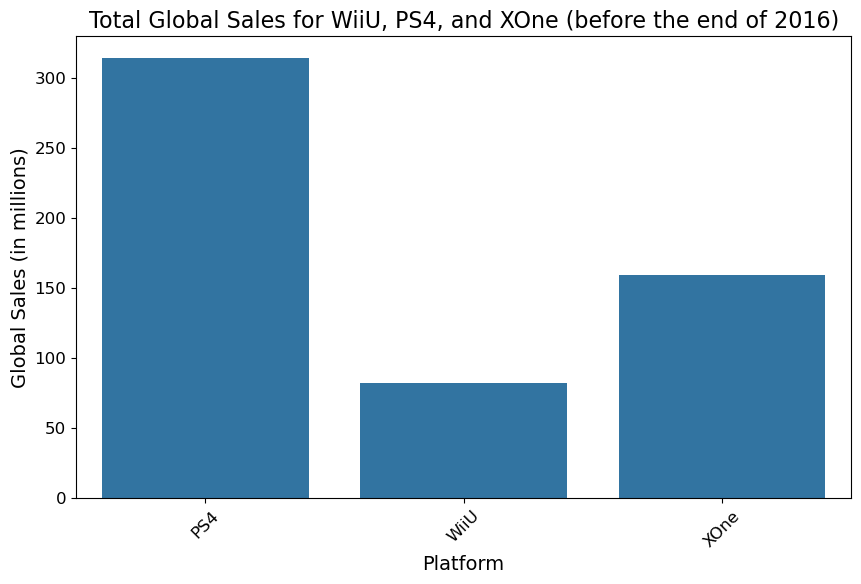

In [454]:
plt.figure(figsize=(10, 6))
sns.barplot(data=filtered_global_sales, x='Platform', y='Global Sales')
plt.title('Total Global Sales for WiiU, PS4, and XOne (before the end of 2016)', fontsize=16)
plt.xlabel('Platform', fontsize=14)
plt.ylabel('Global Sales (in millions)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Total Global Sales for WiiU, PS4, and XOne (before the end of 2016)', transparent=True, bbox_inches='tight')
plt.show()


In [263]:
nintendo_global_sales = global_sales[global_sales['Platform'].isin(['NES', 'SNES', 'N64', 'GC', 'Wii', 'WiiU', 'GB', 'GBA', 'DS', '3DS'])].sort_values(by='Global Sales', ascending=False)
nintendo_global_sales

,Platform,Global Sales
17,Wii,908.13
2,DS,807.10
4,GBA,318.50
1,3DS,259.09
3,GB,255.45
7,NES,251.07
6,N64,218.88
16,SNES,200.05
5,GC,199.36
18,WiiU,82.16


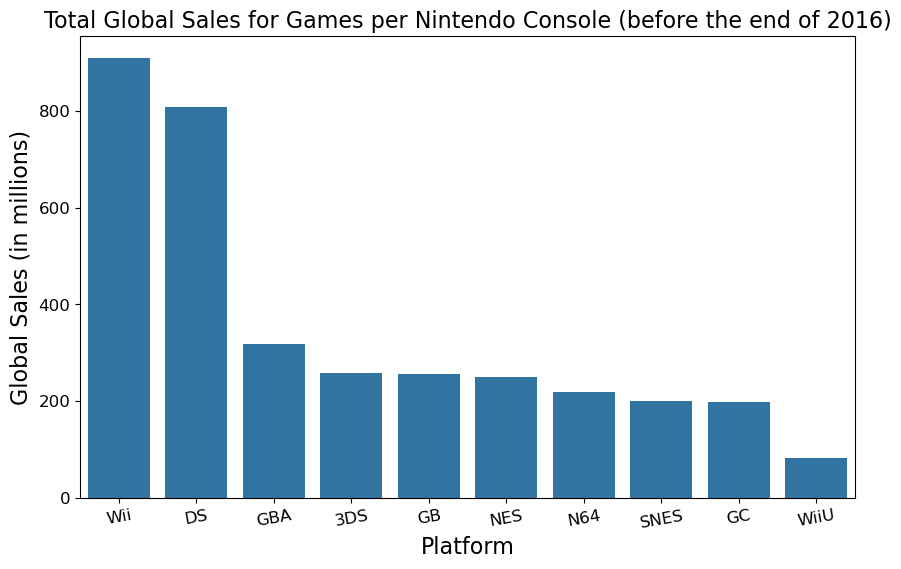

In [449]:
plt.figure(figsize=(10, 6))
sns.barplot(data=nintendo_global_sales, x='Platform', y='Global Sales')
plt.title('Total Global Sales for Games per Nintendo Console (before the end of 2016)', fontsize=16)
plt.xlabel('Platform', fontsize=16)
plt.ylabel('Global Sales (in millions)', fontsize=16)
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Total Global Sales for Games per Nintendo Console (before the end of 2016)', transparent=True)
plt.show()

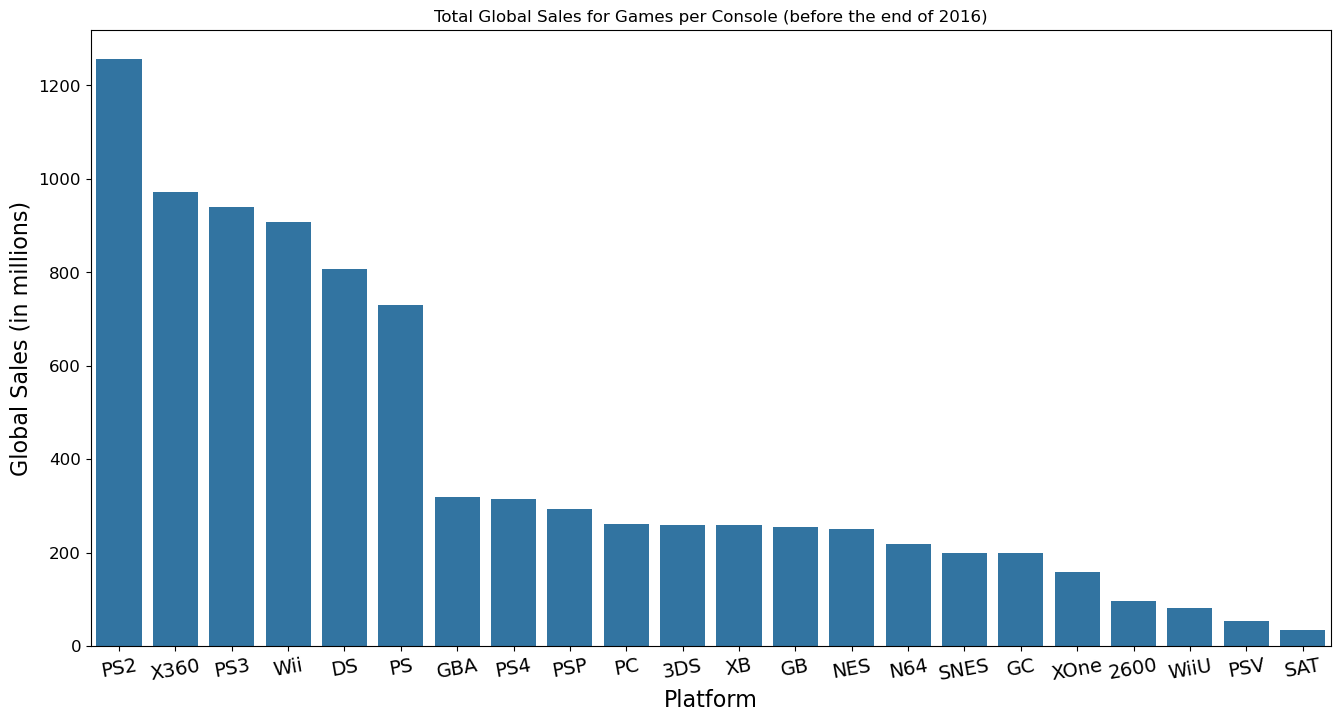

In [374]:
plt.figure(figsize=(16, 8))
sns.barplot(data=sorted_global_sales, x='Platform', y='Global Sales')
plt.title('Total Global Sales for Games per Console (before the end of 2016)', fontsize=12)
plt.xlabel('Platform', fontsize=16)
plt.ylabel('Global Sales (in millions)', fontsize=16)
plt.xticks(rotation=10, fontsize=14)
plt.yticks(fontsize=12)
plt.savefig('Total Global Sales for Games per Console (before the end of 2016)', transparent=True)
plt.show()

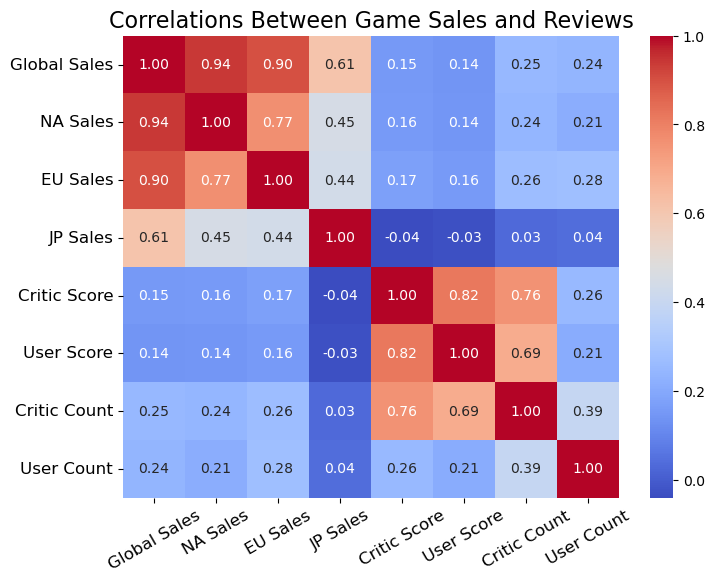

In [473]:
# Prepare data for correlation
correlation_data = games[['Global Sales', 'NA Sales', 'EU Sales', 'JP Sales', 'Critic Score', 'User Score', 'Critic Count', 'User Count']]
correlation_matrix = correlation_data.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
plt.title('Correlations Between Game Sales and Reviews', fontsize=16)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Correlations Between Game Sales and Reviews', transparent=True, bbox_inches='tight')
plt.show()

## Comparing Games By Publisher

In [365]:
activision = games[games['Publisher'] == 'Activision']
activision_games = activision[['Name', 'Platform', 'Publisher', 'Global Sales']]
activision_ps4 = activision_games[activision_games['Platform'] == 'PS4']
activision_XOne = activision_games[activision_games['Platform'] == 'XOne']
activision_WiiU = activision_games[activision_games['Platform'] == 'WiiU']

taketwo = games[games['Publisher'] == 'Take-Two Interactive']
taketwo_games = taketwo[['Name', 'Platform', 'Publisher', 'Global Sales']]
taketwo_ps4 = taketwo_games[taketwo_games['Platform'] == 'PS4']
taketwo_XOne = taketwo_games[taketwo_games['Platform'] == 'XOne']
taketwo_WiiU = taketwo_games[taketwo_games['Platform'] == 'WiiU']

bethesda = games[games['Publisher'] == 'Bethesda Softworks']
bethesda_games = bethesda[['Name', 'Platform', 'Publisher', 'Global Sales']]
bethesda_ps4 = bethesda_games[bethesda_games['Platform'] == 'PS4']
bethesda_XOne = bethesda_games[bethesda_games['Platform'] == 'XOne']
bethesda_WiiU = bethesda_games[bethesda_games['Platform'] == 'WiiU']

ea = games[games['Publisher'] == 'Electronic Arts']
ea_games = ea[['Name', 'Platform', 'Publisher', 'Global Sales']]
ea_ps4 = ea_games[ea_games['Platform'] == 'PS4']
ea_XOne = ea_games[ea_games['Platform'] == 'XOne']
ea_WiiU = ea_games[ea_games['Platform'] == 'WiiU']

ubisoft = games[games['Publisher'] == 'Ubisoft']
ubisoft_games = ubisoft[['Name', 'Platform', 'Publisher', 'Global Sales']]
ubisoft_ps4 = ubisoft_games[ubisoft_games['Platform'] == 'PS4']
ubisoft_XOne = ubisoft_games[ubisoft_games['Platform'] == 'XOne']
ubisoft_WiiU = ubisoft_games[ubisoft_games['Platform'] == 'WiiU']

capcom = games[games['Publisher'] == 'Capcom']
capcom_games = capcom[['Name', 'Platform', 'Publisher', 'Global Sales']]
capcom_ps4 = capcom_games[capcom_games['Platform'] == 'PS4']
capcom_XOne = capcom_games[capcom_games['Platform'] == 'XOne']
capcom_WiiU = capcom_games[capcom_games['Platform'] == 'WiiU']

sega = games[games['Publisher'] == 'Sega']
sega_games = sega[['Name', 'Platform', 'Publisher', 'Global Sales']]
sega_ps4 = sega_games[sega_games['Platform'] == 'PS4']
sega_XOne = sega_games[sega_games['Platform'] == 'XOne']
sega_WiiU = sega_games[sega_games['Platform'] == 'WiiU']

## Visualizing Games By Publisher

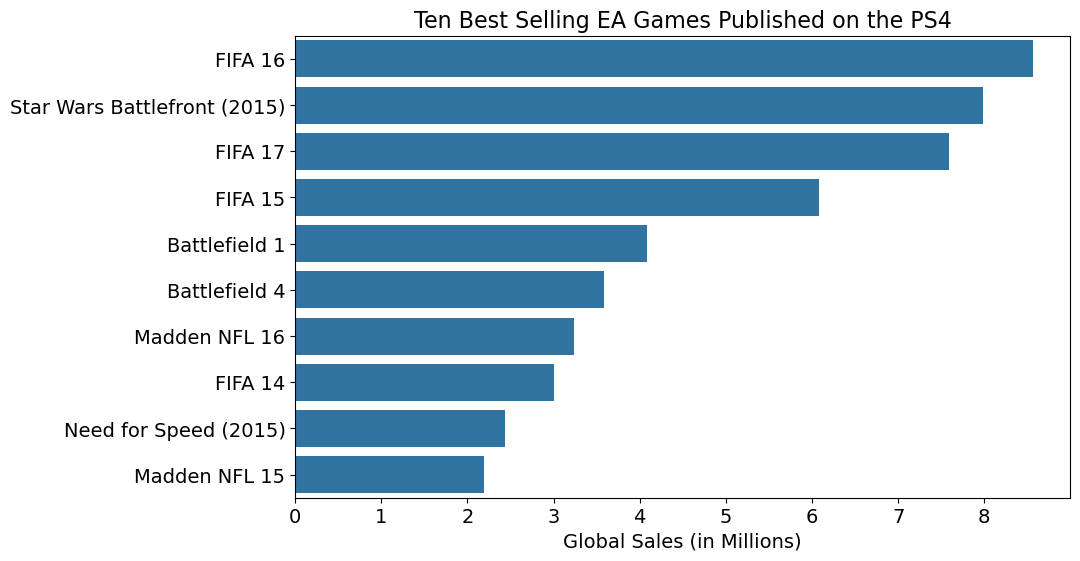

In [453]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ea_ps4['Global Sales'], y=ea_ps4['Name'].head(10))
plt.title('Ten Best Selling EA Games Published on the PS4', fontsize=16)
plt.xlabel('Global Sales (in Millions)', fontsize=14)
plt.ylabel('')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig('Ten Best Selling EA Games Published on the PS4', transparent=True, bbox_inches='tight')
plt.show()

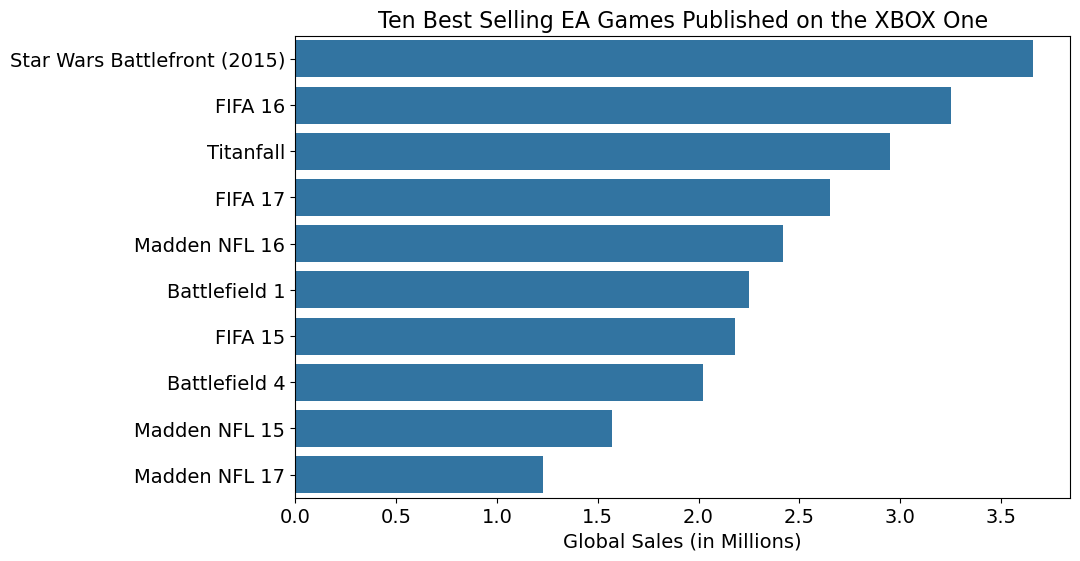

In [455]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ea_XOne['Global Sales'], y=ea_XOne['Name'].head(10))
plt.title('Ten Best Selling EA Games Published on the XBOX One', fontsize=16)
plt.xlabel('Global Sales (in Millions)', fontsize=14)
plt.ylabel('')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig('Ten Best Selling EA Games Published on the XBOX One', transparent=True, bbox_inches='tight')
plt.show()

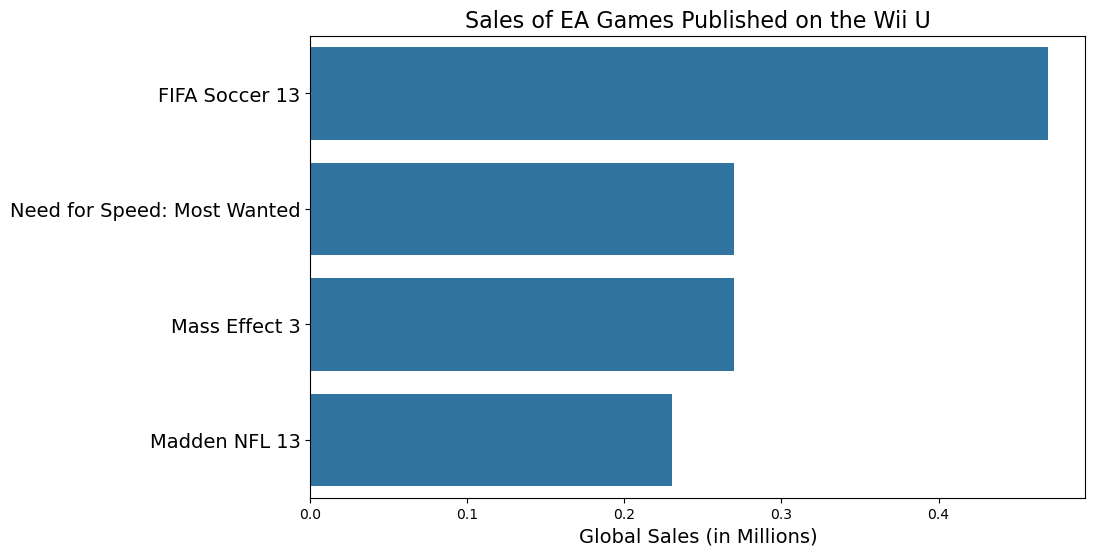

In [456]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ea_WiiU['Global Sales'], y=ea_WiiU['Name'])
plt.title('Sales of EA Games Published on the Wii U', fontsize=16)
plt.xlabel('Global Sales (in Millions)', fontsize=14)
plt.ylabel('')
plt.yticks(fontsize=14)
plt.savefig('Sales of EA Games Published on the Wii U', transparent=True, bbox_inches='tight')
plt.show()

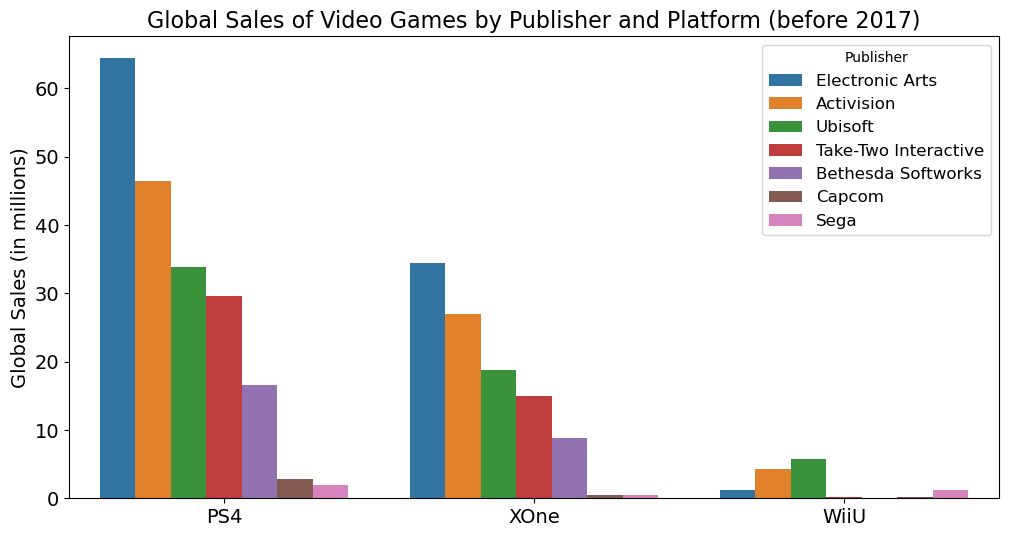

In [459]:
publishers = ['Electronic Arts', 'Activision', 'Ubisoft', 'Take-Two Interactive', 'Bethesda Softworks', 'Capcom', 'Sega']
filtered_games = games[games['Publisher'].isin(publishers)]

desired_platforms = ['PS4', 'XOne', 'WiiU']
filtered_games = filtered_games[filtered_games['Platform'].isin(desired_platforms)]

grouped_data = filtered_games.groupby(['Publisher', 'Platform'], as_index=False)['Global Sales'].sum()

grouped_data['Platform'] = pd.Categorical(grouped_data['Platform'], categories=desired_platforms, ordered=True)
grouped_data['Publisher'] = pd.Categorical(grouped_data['Publisher'], categories=publishers, ordered=True)

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_data, x='Platform', y='Global Sales', hue='Publisher')
plt.title('Global Sales of Video Games by Publisher and Platform (before 2017)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('Global Sales (in millions)', fontsize=14)
plt.legend(title='Publisher', fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig('Global Sales of Video Games by Publisher and Platform (before 2017)', transparent=True, bbox_inches='tight')
plt.show()

## Visualizing Data Comparing Nintendo (Wii U), Sony (PS4) and Microsoft (XBOX One) Games

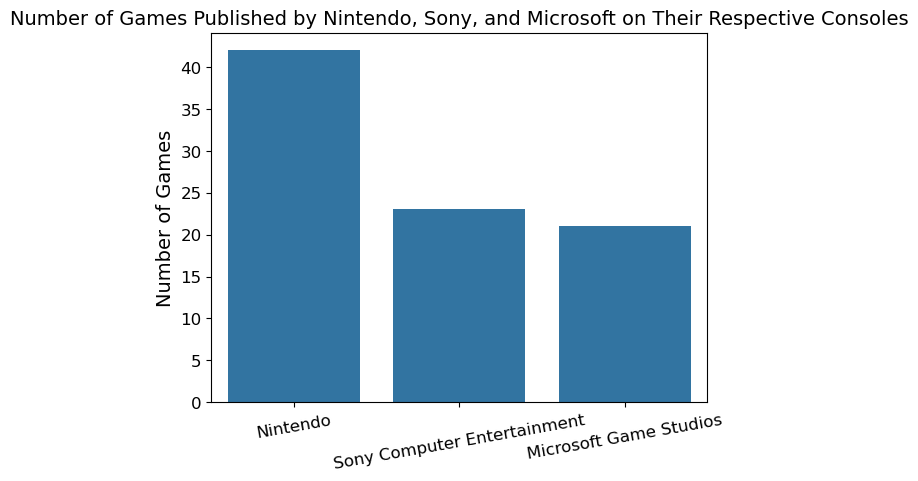

In [461]:
publishers_2 = ['Nintendo', 'Sony Computer Entertainment', 'Microsoft Game Studios']
counts_2 = [nintendo_count.shape[0], sony_count.shape[0], microsoft_count.shape[0]]

sns.barplot(x=publishers_2, y=counts_2)
plt.title('Number of Games Published by Nintendo, Sony, and Microsoft on Their Respective Consoles', fontsize=14)
plt.xlabel('')
plt.ylabel('Number of Games', fontsize=14)
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Number of Games Published by Nintendo, Sony, and Microsoft on Their Respective Consoles', transparent=True, bbox_inches='tight')
plt.show()

In [295]:
nintendo_sales = nintendo_count['Global Sales'].sum()
sony_sales = sony_count['Global Sales'].sum()
microsoft_sales = microsoft_count['Global Sales'].sum()

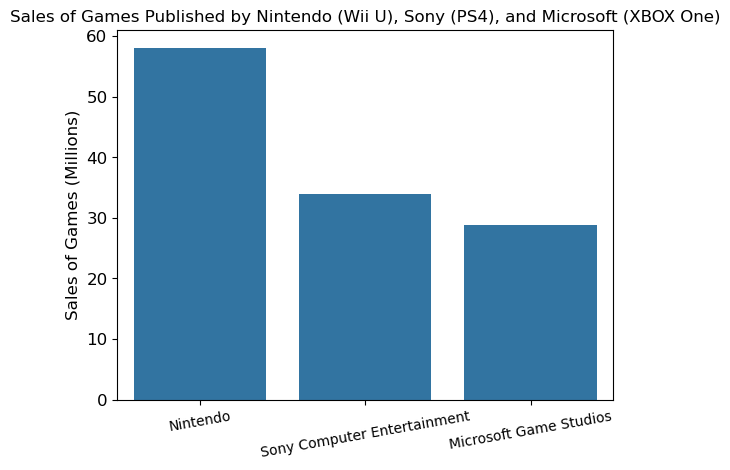

In [406]:
publishers_2 = ['Nintendo', 'Sony Computer Entertainment', 'Microsoft Game Studios']
counts_3 = [nintendo_sales, sony_sales, microsoft_sales]

sns.barplot(x=publishers_2, y=counts_3)
plt.title('Sales of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XBOX One)')
plt.xlabel('')
plt.ylabel('Sales of Games (Millions)', fontsize=12)
plt.xticks(rotation=10)
plt.yticks(fontsize=12)
plt.savefig('Sales of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XBOX One)', transparent=True)
plt.show()

In [297]:
nintendo_reviews = nintendo_count['Critic Score'].mean()
nintendo_reviews_user = nintendo_count['User Score'].mean()

In [298]:
sony_reviews = sony_count['Critic Score'].mean()
sony_reviews_user = sony_count['User Score'].mean()

In [299]:
microsoft_reviews = microsoft_count['Critic Score'].mean()
microsoft_reviews_user = microsoft_count['User Score'].mean()

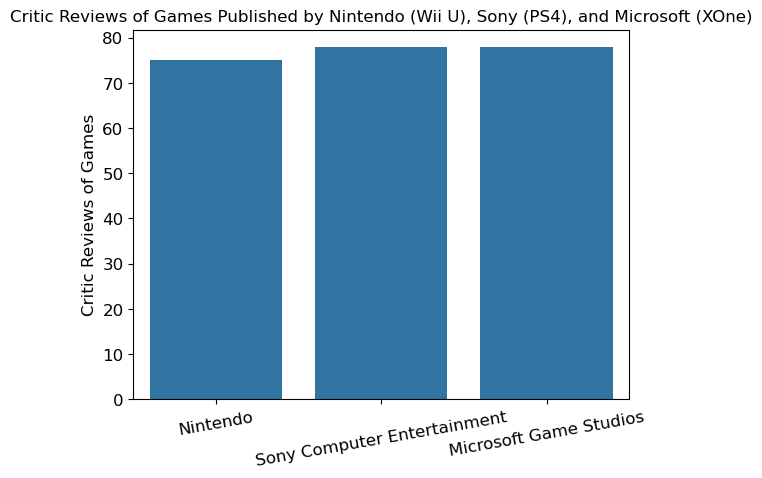

In [462]:
publishers_2 = ['Nintendo', 'Sony Computer Entertainment', 'Microsoft Game Studios']
counts_4 = [nintendo_reviews, sony_reviews, microsoft_reviews]

sns.barplot(x=publishers_2, y=counts_4)
plt.title('Critic Reviews of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XOne)')
plt.xlabel('')
plt.ylabel('Critic Reviews of Games', fontsize=12)
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Critic Reviews of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XOne)', transparent=True, bbox_inches='tight')
plt.show()

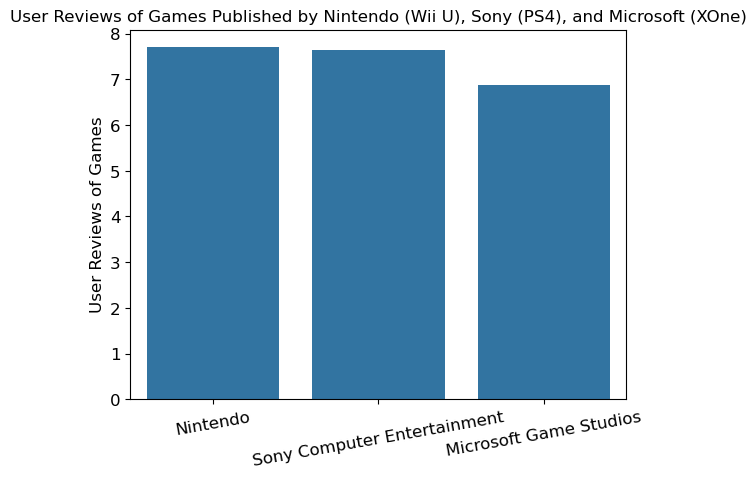

In [463]:
publishers_2 = ['Nintendo', 'Sony Computer Entertainment', 'Microsoft Game Studios']
counts_5 = [nintendo_reviews_user, sony_reviews_user, microsoft_reviews_user]

sns.barplot(x=publishers_2, y=counts_5)
plt.title('User Reviews of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XOne)')
plt.xlabel('')
plt.ylabel('User Reviews of Games', fontsize=12)
plt.xticks(rotation=10, fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('User Reviews of Games Published by Nintendo (Wii U), Sony (PS4), and Microsoft (XOne)', transparent=True, bbox_inches='tight')
plt.show()

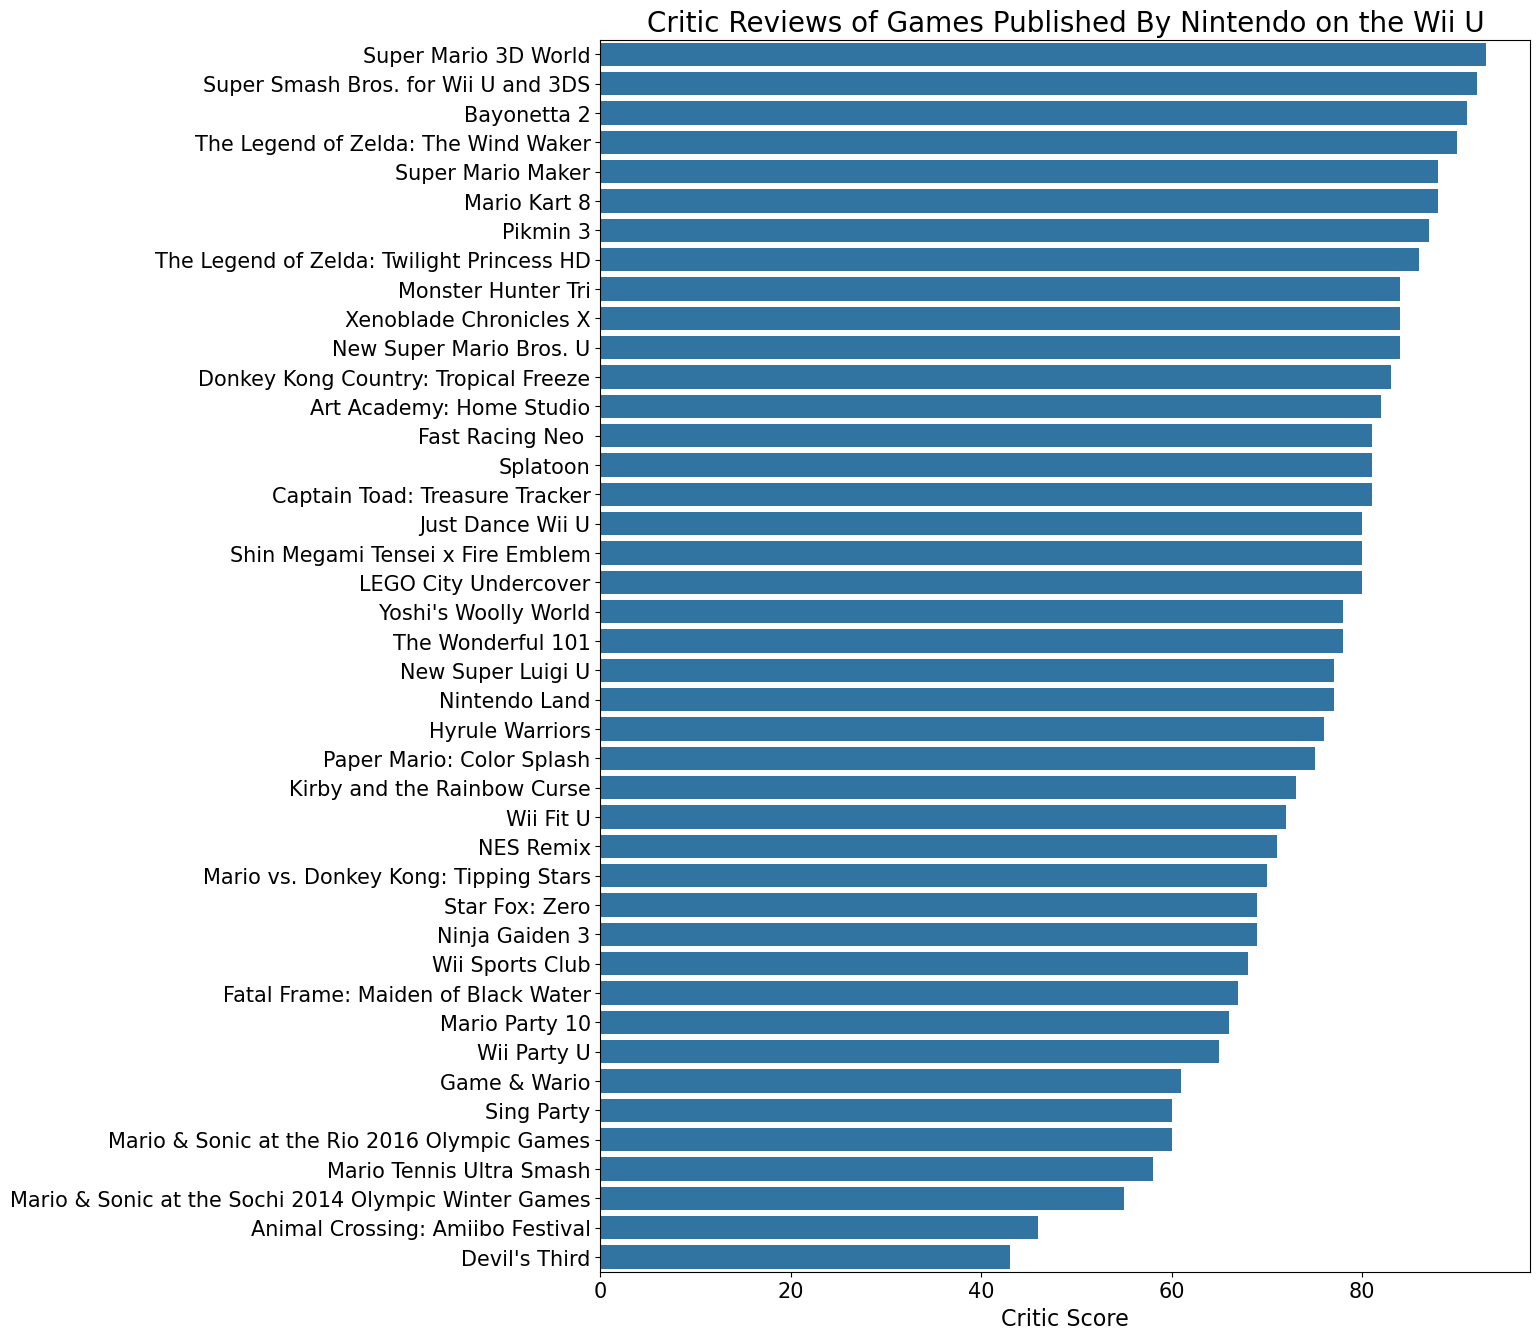

In [468]:
nintendo_reviews_2 = nintendo_count.sort_values(by='Critic Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 16))
sns.barplot(x=nintendo_reviews_2['Critic Score'], y=nintendo_reviews_2['Name'])
plt.title('Critic Reviews of Games Published By Nintendo on the Wii U', fontsize=20)
plt.xlabel('Critic Score', fontsize=16)
plt.ylabel('')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('Critic Reviews of Games Published By Nintendo on the Wii U', transparent=True, bbox_inches='tight')
plt.show()

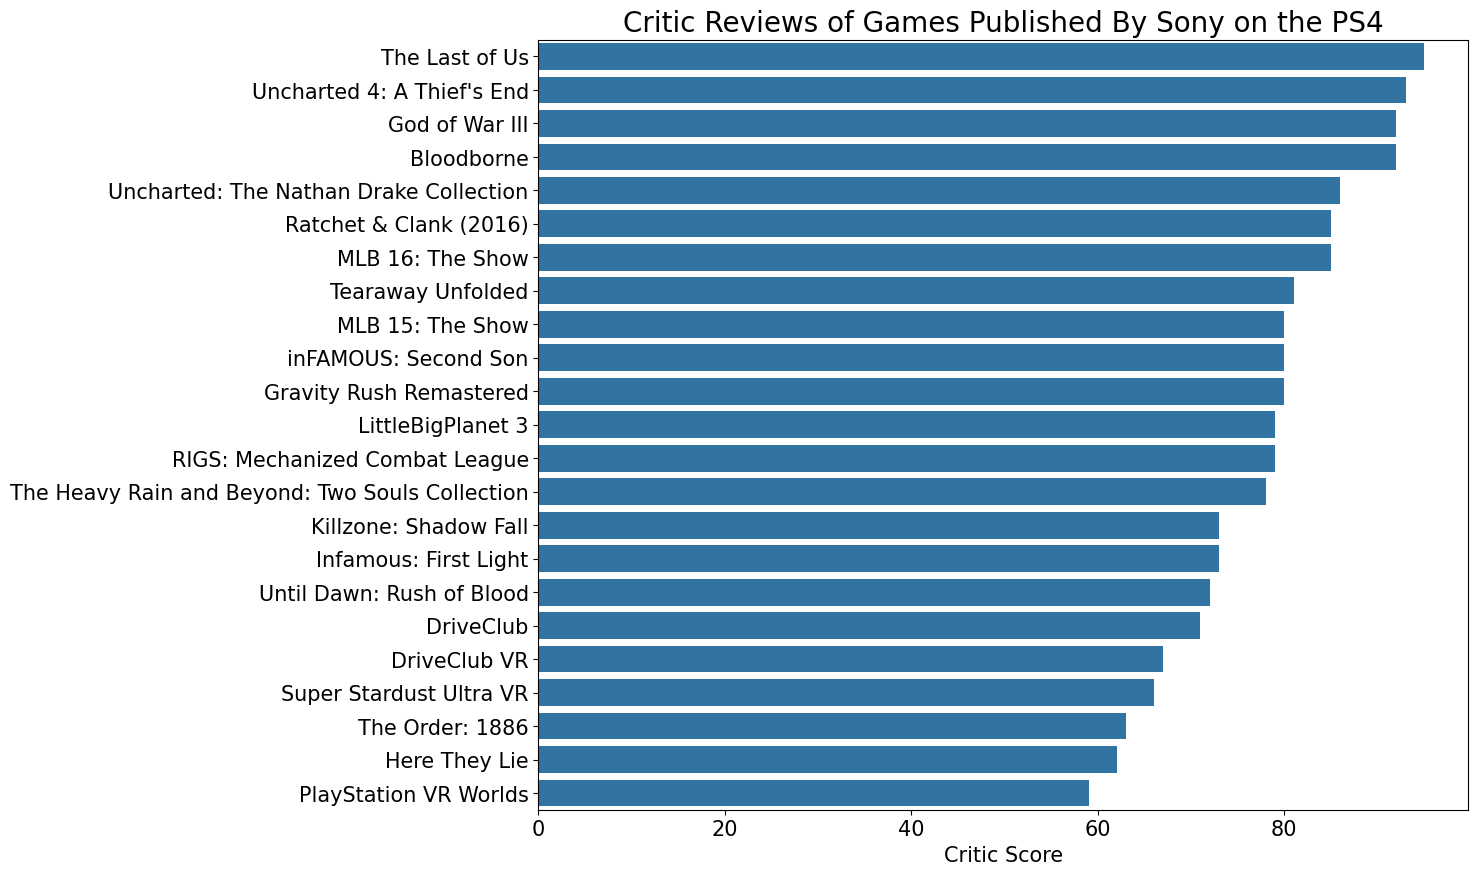

In [467]:
sony_reviews_2 = sony_count.sort_values(by='Critic Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=sony_reviews_2['Critic Score'], y=sony_reviews_2['Name'])
plt.title('Critic Reviews of Games Published By Sony on the PS4', fontsize=20)
plt.xlabel('Critic Score', fontsize=15)
plt.ylabel('')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('Critic Reviews of Games Published By Sony on the PS4', transparent=True, bbox_inches='tight')
plt.show()

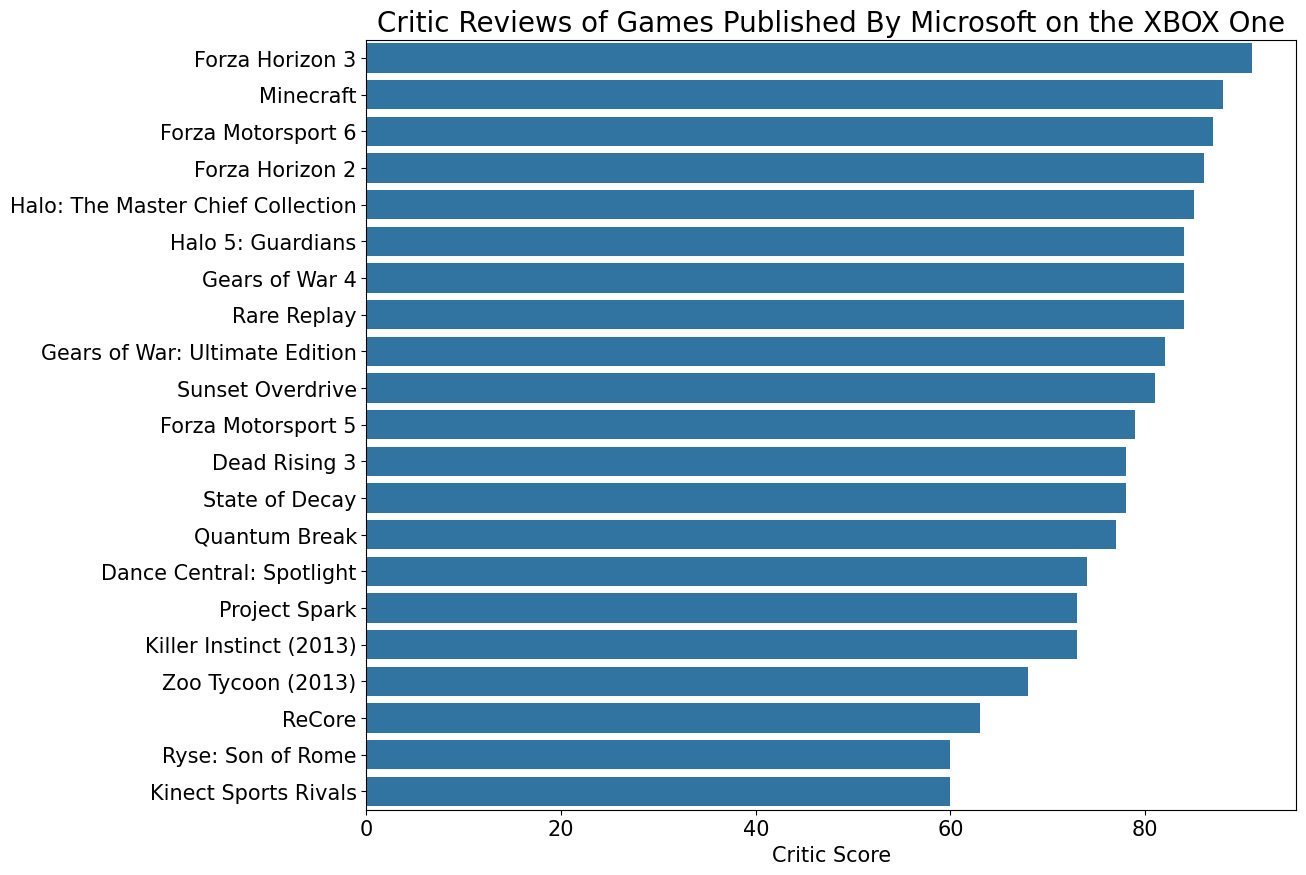

In [470]:
microsoft_reviews_2 = microsoft_count.sort_values(by='Critic Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=microsoft_reviews_2['Critic Score'], y=microsoft_reviews_2['Name'])
plt.title('Critic Reviews of Games Published By Microsoft on the XBOX One', fontsize=20)
plt.xlabel('Critic Score', fontsize=15)
plt.ylabel('')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('Critic Reviews of Games Published By Microsoft on the XBOX One', transparent=True, bbox_inches='tight')
plt.show()

C:\Users\joshp\AppData\Local\Temp\ipykernel_39660\739377803.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nintendo_count['User_Score'] = pd.to_numeric(nintendo_count['User Score'], errors='coerce')


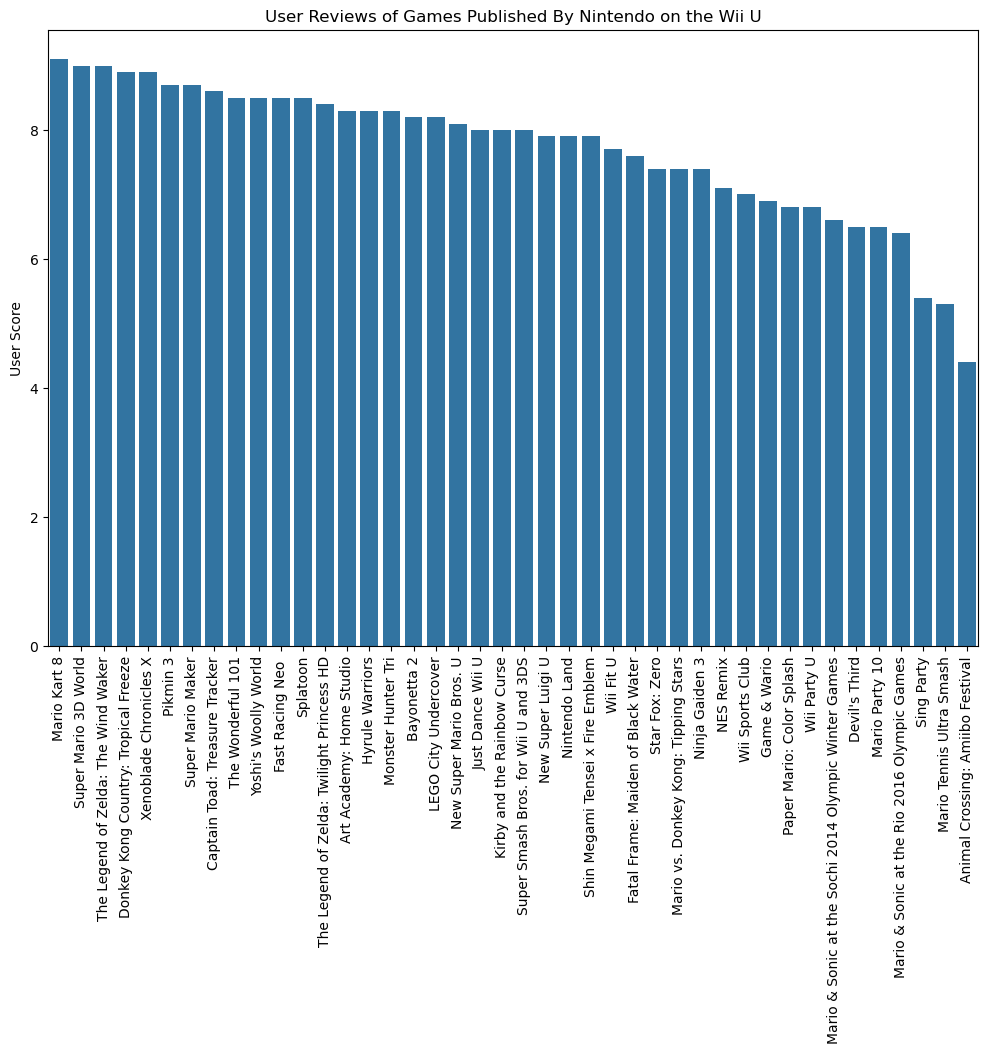

In [305]:
nintendo_count['User_Score'] = pd.to_numeric(nintendo_count['User Score'], errors='coerce')

nintendo_reviews_3 = nintendo_count.sort_values(by='User_Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 8))
sns.barplot(x=nintendo_reviews_3['Name'], y=nintendo_reviews_3['User Score'])
plt.title('User Reviews of Games Published By Nintendo on the Wii U')
plt.xlabel('')
plt.ylabel('User Score')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()

C:\Users\joshp\AppData\Local\Temp\ipykernel_39660\2950566390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sony_count['User_Score'] = pd.to_numeric(sony_count['User Score'], errors='coerce')


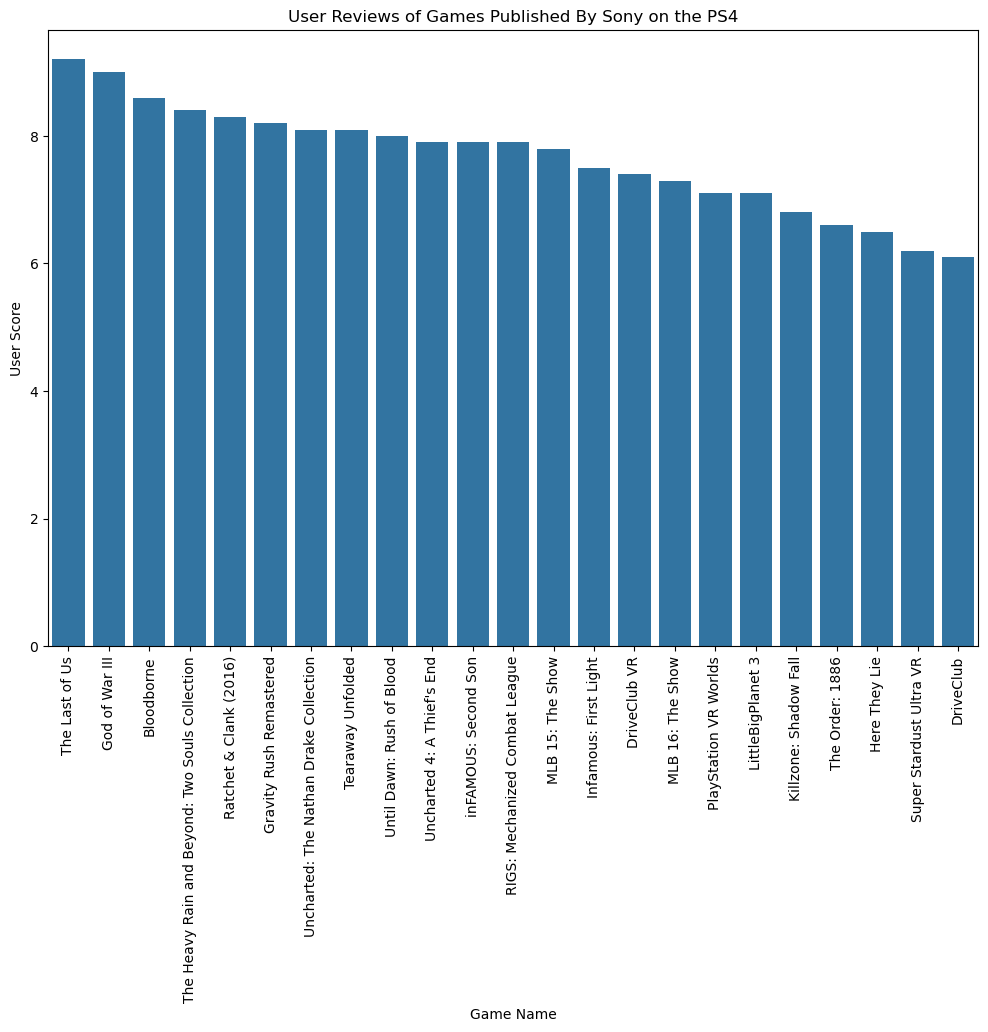

In [306]:
sony_count['User_Score'] = pd.to_numeric(sony_count['User Score'], errors='coerce')

sony_reviews_3 = sony_count.sort_values(by='User Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 8))
sns.barplot(x=sony_reviews_3['Name'], y=sony_reviews_3['User Score'])
plt.title('User Reviews of Games Published By Sony on the PS4')
plt.xlabel('Game Name')
plt.ylabel('User Score')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()

C:\Users\joshp\AppData\Local\Temp\ipykernel_39660\3171463041.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft_count['User Score'] = pd.to_numeric(microsoft_count['User Score'], errors='coerce')


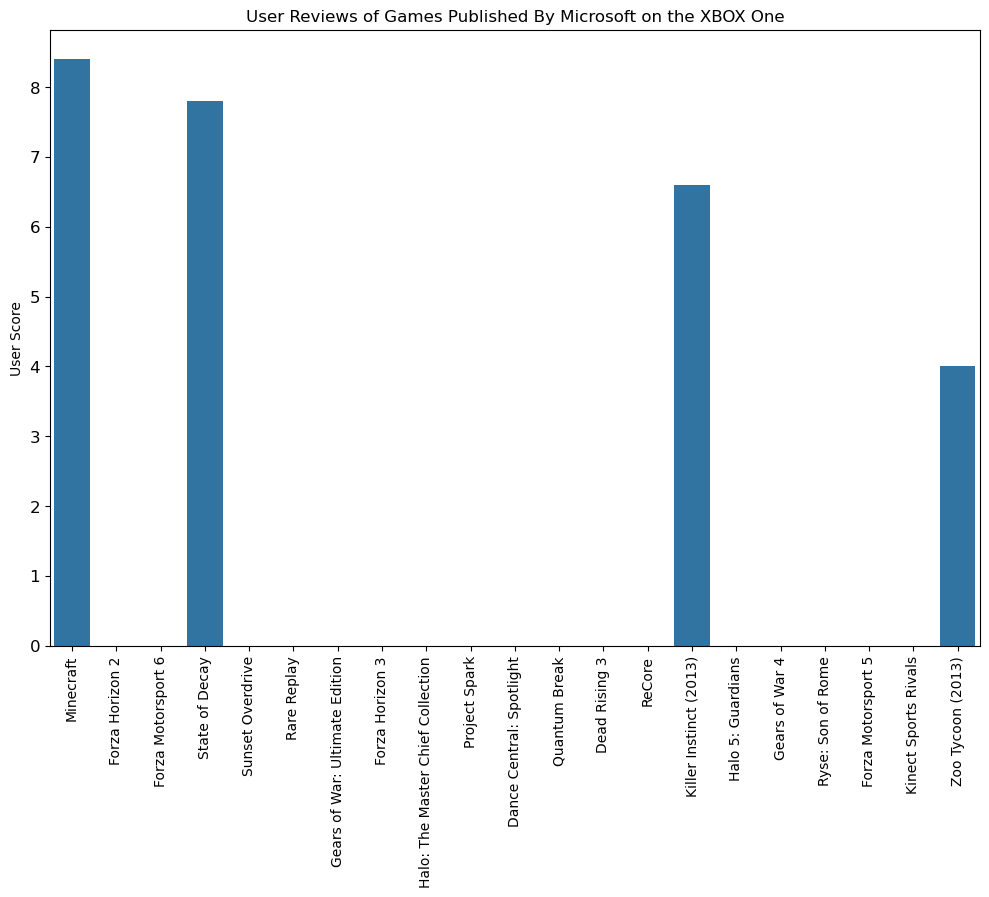

In [429]:
microsoft_count['User Score'] = pd.to_numeric(microsoft_count['User Score'], errors='coerce')

microsoft_reviews_3 = microsoft_count.sort_values(by='User Score', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 8))
sns.barplot(x=microsoft_reviews_3['Name'], y=microsoft_reviews_3['User_Score'])
plt.title('User Reviews of Games Published By Microsoft on the XBOX One')
plt.xlabel('')
plt.ylabel('User Score')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()

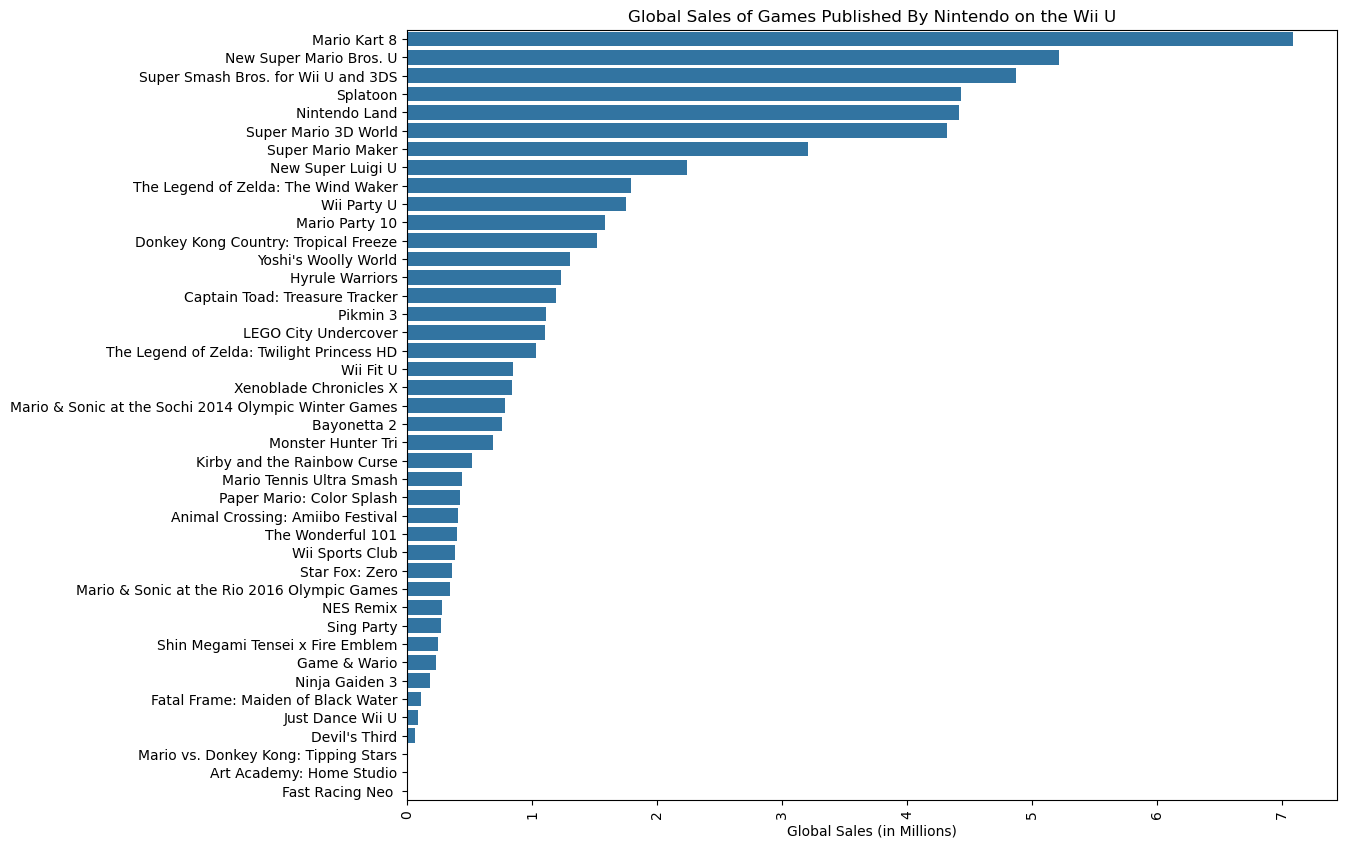

In [308]:
nintendo_reviews_4 = nintendo_count.sort_values(by='Global Sales', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=nintendo_reviews_3['Global Sales'], y=nintendo_reviews_2['Name'])
plt.title('Global Sales of Games Published By Nintendo on the Wii U')
plt.xlabel('Global Sales (in Millions)')
plt.ylabel('')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()

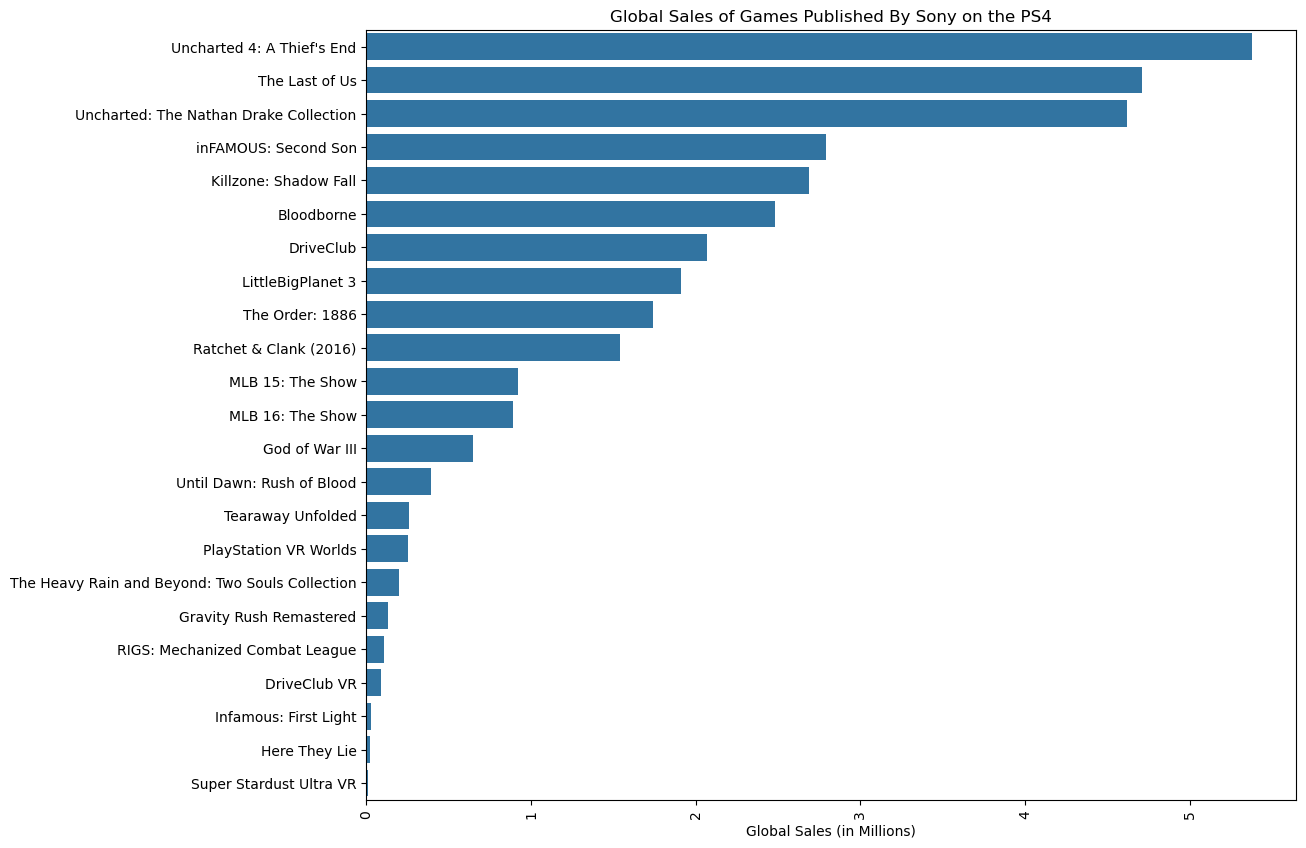

In [309]:
sony_reviews_4 = sony_count.sort_values(by='Global Sales', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=sony_reviews_3['Global Sales'], y=sony_reviews_2['Name'])
plt.title('Global Sales of Games Published By Sony on the PS4')
plt.xlabel('Global Sales (in Millions)')
plt.ylabel('')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()

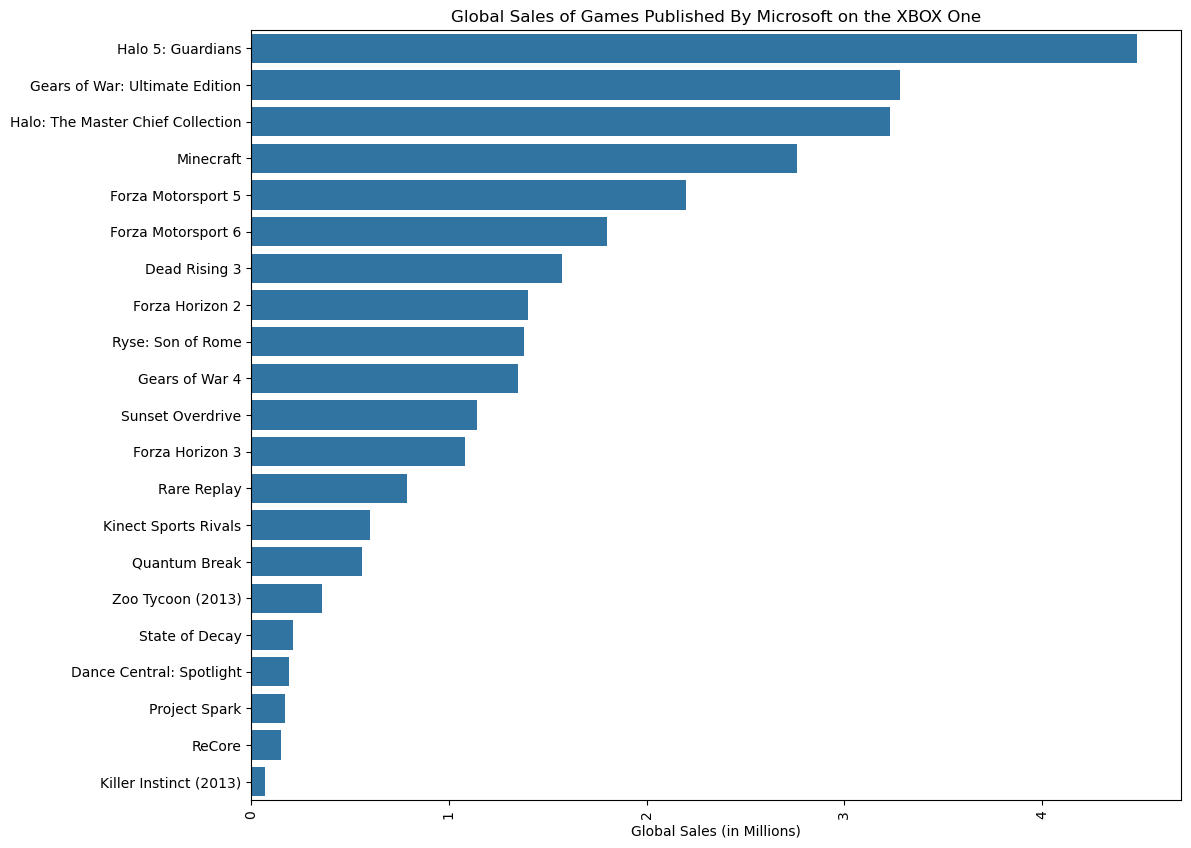

In [310]:
microsoft_reviews_4 = microsoft_count.sort_values(by='Global Sales', ascending=False)

# Corrected barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=microsoft_reviews_3['Global Sales'], y=microsoft_reviews_2['Name'])
plt.title('Global Sales of Games Published By Microsoft on the XBOX One')
plt.xlabel('Global Sales (in Millions)')
plt.ylabel('')
plt.xticks(rotation=90)
plt.yticks(fontsize=12)
plt.show()